**Mô Hình 1: U-Net + MiT-B3 + PSCSE (Mô hình chính)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

!pip install -U albumentations
!pip install -U timm
!pip install -U opencv-python-headless
!pip install pretrainedmodels
!pip install efficientnet-pytorch


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60945 sha256=634c31c0784e302bea6de6ddb62dccccfc56107bdf5f32172797d4b4734cdee3
  Stored in directory: /root/.cache/pip/wheels/4c/01/56/40a48f75dbdfe167a0cb70d3b48913369a00ec5c4e9fed5f2b
Successfully built pretrainedmodels
  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=6f881ef0fe8f149547edfd76c641d9ddc76d17a94c37105adb5d92f9a80748a4
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet-pytorch


In [ ]:
# import os, sys

# PROJECT_ROOT = os.getcwd()  # đang là thư mục DFUTissueSegNet
# CODES_DIR = os.path.join(PROJECT_ROOT, "Codes")

# sys.path.insert(0, PROJECT_ROOT)
# sys.path.insert(0, CODES_DIR)

# print("PROJECT_ROOT:", PROJECT_ROOT)
# print("CODES_DIR:", CODES_DIR)
import sys

PROJECT_ROOT = "/content/drive/MyDrive/DFUTissueSegNet"
CODES_DIR = PROJECT_ROOT + "/Codes"

sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, CODES_DIR)

print(PROJECT_ROOT)
print(CODES_DIR)

/content/drive/MyDrive/DFUTissueSegNet
/content/drive/MyDrive/DFUTissueSegNet/Codes


In [ ]:
# ===== Basic imports (PHẢI CÓ) =====
import os
import cv2
import random
import numpy as np
from datetime import datetime

# ===== PyTorch =====
import torch
from torch.utils.data import DataLoader

# ===== Segmentation Models =====
import segmentation_models_pytorch as smp

In [ ]:
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset as BaseDataset
import albumentations as albu
import cv2
import numpy as np
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.utils import metrics, losses, base
import random
import matplotlib.pyplot as plt
import os
from copy import deepcopy
from datetime import datetime
import torch.nn.functional as F

%matplotlib inline

**Dataloader**

In [ ]:
import os
import cv2
import numpy as np
import torch.utils.data

class Dataset(torch.utils.data.Dataset):

    def __init__(
        self,
        list_IDs,
        images_dir,
        masks_dir,
        augmentation=None,
        preprocessing=None,
        to_categorical=False,
        resize=(256, 256),
        n_classes=4,
        default_img=None,
        default_mask=None,
    ):
        self.ids = list_IDs
        self.images_fps = [os.path.join(images_dir, i) for i in self.ids]
        self.masks_fps = [os.path.join(masks_dir, i) for i in self.ids]

        self.augmentation = augmentation
        self.preprocessing = preprocessing
        self.to_categorical = to_categorical
        self.resize = resize
        self.n_classes = n_classes
        self.default_img = default_img
        self.default_mask = default_mask

    def __getitem__(self, i):
        try:
            image = cv2.imread(self.images_fps[i])
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            mask = cv2.imread(self.masks_fps[i], cv2.IMREAD_GRAYSCALE)
        except:
            image = self.default_img.copy()
            mask = self.default_mask.copy()

        # resize
        image = cv2.resize(image, self.resize, interpolation=cv2.INTER_NEAREST)
        mask = cv2.resize(mask, self.resize, interpolation=cv2.INTER_NEAREST)

        # add channel dim for mask (H,W) → (H,W,1)
        mask = np.expand_dims(mask, axis=-1)

        # augmentation
        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample["image"], sample["mask"]

        # preprocessing (normalize + to_tensor)
        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample["image"], sample["mask"]

        # one-hot (SAU preprocessing)
        if self.to_categorical:
            # mask: (1,H,W) → (H,W)
            mask = mask.squeeze(0).astype("int64")

            # (H,W) → (H,W,C)
            mask = np.eye(self.n_classes)[mask]

            # (H,W,C) → (C,H,W)
            mask = np.transpose(mask, (2, 0, 1)).astype("float32")

        return image, mask

    def __len__(self):
        return len(self.ids)


**Augmentation**

In [ ]:
def get_training_augmentation():
    train_transform = [

        albu.OneOf(
            [
                albu.HorizontalFlip(p=0.5),
                albu.VerticalFlip(p=0.5),
            ],
            p=0.8,
        ),

        albu.OneOf(
            [
                albu.ShiftScaleRotate(scale_limit=0.5, rotate_limit=0, shift_limit=0, p=0.1, border_mode=0), # scale only
                albu.ShiftScaleRotate(scale_limit=0, rotate_limit=30, shift_limit=0, p=0.1, border_mode=0), # rotate only
                albu.ShiftScaleRotate(scale_limit=0, rotate_limit=0, shift_limit=0.1, p=0.6, border_mode=0), # shift only
                albu.ShiftScaleRotate(scale_limit=0.5, rotate_limit=30, shift_limit=0.1, p=0.2, border_mode=0), # affine transform
            ],
            p=0.9,
        ),

        albu.OneOf(
            [
                albu.Perspective(p=0.2),
                albu.GaussNoise(p=0.2),
                albu.Sharpen(p=0.2),
                albu.Blur(blur_limit=3, p=0.2),
                albu.MotionBlur(blur_limit=3, p=0.2),
            ],
            p=0.5,
        ),

        albu.OneOf(
            [
                albu.CLAHE(p=0.25),
                albu.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.25),
                albu.RandomGamma(p=0.25),
                albu.HueSaturationValue(p=0.25),
            ],
            p=0.3,
        ),

    ]

    return albu.Compose(train_transform, p=0.9) # 90% augmentation probability


def get_validation_augmentation():
    """Add paddings to make image shape divisible by 32"""
    test_transform = [
        # albu.PadIfNeeded(512, 512)
    ]
    return albu.Compose(test_transform)


def to_tensor(x, **kwargs):
    return x.transpose(2, 0, 1).astype('float32')


def get_preprocessing(preprocessing_fn):
    """Construct preprocessing transform

    Args:
        preprocessing_fn (callbale): data normalization function
            (can be specific for each pretrained neural network)
    Return:
        transform: albumentations.Compose

    """

    _transform = [
        albu.Lambda(image=preprocessing_fn),
        albu.Lambda(image=to_tensor, mask=to_tensor),
    ]
    return albu.Compose(_transform)

**Parameters**

In [ ]:

BASE_MODEL = 'MiT+pscse'
ENCODER = 'mit_b3'
ENCODER_WEIGHTS = 'imagenet'

BATCH_SIZE = 16
n_classes = 4

ACTIVATION = 'softmax'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LR = 1e-4
WEIGHT_DECAY = 1e-5

EPOCHS = 500
SAVE_WEIGHTS_ONLY = True


RESIZE = (256, 256)

TO_CATEGORICAL = True

SAVE_BEST_MODEL = True
SAVE_LAST_MODEL = False

PERIOD = 10              # save checkpoint mỗi 10 epoch
RAW_PREDICTION = False
RETRAIN = False

# ===== EARLY STOPPING =====
# EPOCHS = 20
EARLY_STOP = True
PATIENCE = 50

# ======================================================
# Parameters
# BASE_MODEL = 'MiT+pscse'
# ENCODER = 'mit_b3'
# ENCODER_WEIGHTS = 'imagenet'
# BATCH_SIZE = 16
# n_classes = 4
# ACTIVATION = 'softmax' # could be None for logits or 'softmax2d' for multiclass segmentation
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# LR = 0.0001 # learning rate
# EPOCHS = 500
# WEIGHT_DECAY = 1e-5
# SAVE_WEIGHTS_ONLY = True
# RESIZE = (False, (256,256)) # if resize needed
# TO_CATEGORICAL = True
# SAVE_BEST_MODEL = True
# SAVE_LAST_MODEL = False

# PERIOD = 10 # periodically save checkpoints
# RAW_PREDICTION = False # if true, then stores raw predictions (i.e. before applying threshold)
# RETRAIN = False

# # For early stopping
# EARLY_STOP = True # True to activate early stopping
# PATIENCE = 50 # for early stopping

# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context

**Helper function: save a model**

In [ ]:
def save(model_path, epoch, model_state_dict, optimizer_state_dict):

    state = {
        'epoch': epoch + 1,
        'state_dict': deepcopy(model_state_dict),
        'optimizer': deepcopy(optimizer_state_dict),
        }

    torch.save(state, model_path)

**Loss, optimizer, metrics, and callbacks**

In [ ]:
from segmentation_models_pytorch.utils import losses, metrics as smp_metrics, base

# Loss (API cũ không có mode=)
dice_loss = losses.DiceLoss()
ce_loss   = losses.CrossEntropyLoss()

total_loss = base.SumOfLosses(dice_loss, ce_loss)

# metric_list = [
#     smp_metrics.IoU(threshold=0.5),
#     smp_metrics.Fscore(threshold=0.5),
# ]
metrics = [
    smp.utils.metrics.IoU(threshold=0.5),
    smp.utils.metrics.Fscore(threshold=0.5),
]



**Model Run**

In [ ]:
# Create a function to read names from a text file, and add extensions
def read_names(txt_file, ext=".png"):
  with open(txt_file, "r") as f: names = f.readlines()

  names = [name.strip("\n") for name in names] # remove newline

  # Names are without extensions. So, add extensions
  names = [name + ext for name in names]

  return names

In [ ]:
def fix_case_filenames(img_dir, names):
    real_files = {f.lower(): f for f in os.listdir(img_dir)}
    fixed = []
    for n in names:
        if n.lower() in real_files:
            fixed.append(real_files[n.lower()])
        else:
            raise FileNotFoundError(f"❌ File {n} not found in {img_dir}")
    return fixed


**Training**

In [ ]:
# ================== PATH ROOT ==================
PROJECT_ROOT = '/content/drive/MyDrive/DFUTissueSegNet'

# ================== SAVE DIR ==================
save_dir_pred_root = os.path.join(PROJECT_ROOT, 'predictions')
os.makedirs(save_dir_pred_root, exist_ok=True)


# ================== MODEL ==================
aux_params=dict(
    classes=n_classes,
    activation=ACTIVATION,
    dropout=0.1, # dropout ratio, default is None
)

# create segmentation model with pretrained encoder
model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    # aux_params=aux_params,
    classes=n_classes,
    activation=ACTIVATION,
    decoder_attention_type='pscse',
)

preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, ENCODER_WEIGHTS)

model.to(DEVICE)

# Optimizer
optimizer = torch.optim.Adam([
    dict(params=model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY),
])

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    factor=0.1,
    mode='min',
    patience=10,
    min_lr=1e-5
)

seed = random.randint(0, 5000)

print(f'seed: {seed}')

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

# x_train_dir = x_valid_dir = '/content/drive/MyDrive/Wound_tissue_segmentation/Dataset/dataset_MiT_v3+aug-added/PNGImages'
# y_train_dir = y_valid_dir = '/content/drive/MyDrive/Wound_tissue_segmentation/Dataset/dataset_MiT_v3+aug-added/SegmentationClass'

# x_test_dir = '/content/drive/MyDrive/Wound_tissue_segmentation/Dataset/dataset_MiT_v3+aug-added/test_images'
# y_test_dir = '/content/drive/MyDrive/Wound_tissue_segmentation/Dataset/dataset_MiT_v3+aug-added/test_labels'
# ================== DATASET PATH ==================
BASE_DATASET = os.path.join(
    PROJECT_ROOT,
    'DFUTissue',
    'Labeled',
    'Padded'
)

x_train_dir = os.path.join(BASE_DATASET, 'Images', 'TrainVal')
y_train_dir = os.path.join(BASE_DATASET, 'Annotations', 'TrainVal')

x_valid_dir = x_train_dir
y_valid_dir = y_train_dir

x_test_dir = os.path.join(BASE_DATASET, 'Images', 'Test')
y_test_dir = os.path.join(BASE_DATASET, 'Annotations', 'Test')

# Read train, test, and val names
# dir_txt = '/content/drive/MyDrive/Wound_tissue_segmentation/Dataset/dataset_MiT_v3+aug-added'
# ================== TXT FILES ==================
dir_txt = os.path.join(PROJECT_ROOT, 'DFUTissue', 'Labeled')
list_IDs_train = read_names(os.path.join(dir_txt, 'labeled_train_names.txt'), ext='.png')
list_IDs_val = read_names(os.path.join(dir_txt, 'labeled_val_names.txt'), ext='.png')
list_IDs_test = read_names(os.path.join(dir_txt, 'test_names.txt'), ext='.png')

random.seed(seed) # seed for random number generator
random.shuffle(list_IDs_train) # shuffle train names

print('No. of training images: ', len(list_IDs_train))
print('No. of validation images: ', len(list_IDs_val))
print('No. of test images: ', len(list_IDs_test))

# Create a unique model name
model_name = BASE_MODEL + '_padded_aug_' + ENCODER + '_sup_' + datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
print(model_name)

# Default images
# DEFAULT_IMG_TRAIN = cv2.imread(os.path.join(x_train_dir, list_IDs_train[0]))[:,:,::-1]
# DEFAULT_MASK_TRAIN = cv2.imread(os.path.join(y_train_dir, list_IDs_train[0]), 0)
# DEFAULT_IMG_VAL = cv2.imread(os.path.join(x_valid_dir, list_IDs_val[0]))[:,:,::-1]
# DEFAULT_MASK_VAL = cv2.imread(os.path.join(y_valid_dir, list_IDs_val[0]), 0)
DEFAULT_IMG_TRAIN = cv2.imread(os.path.join(x_train_dir, list_IDs_train[0]))[:, :, ::-1]
DEFAULT_MASK_TRAIN = cv2.imread(os.path.join(y_train_dir, list_IDs_train[0]), 0)

DEFAULT_IMG_VAL = cv2.imread(os.path.join(x_valid_dir, list_IDs_val[0]))[:, :, ::-1]
DEFAULT_MASK_VAL = cv2.imread(os.path.join(y_valid_dir, list_IDs_val[0]), 0)
# Checkpoint directory
checkpoint_loc = os.path.join(PROJECT_ROOT, 'checkpoints', model_name)
# checkpoint_loc = os.path.join(PROJECT_ROOT, 'checkpoints', model_name)
os.makedirs(checkpoint_loc, exist_ok=True)
# Create checkpoint directory if does not exist
if not os.path.exists(checkpoint_loc): os.makedirs(checkpoint_loc)

# if SAVE_BEST_MODEL_ONLY: checkpoint_path = os.path.join(checkpoint_loc, 'best_model.pth')
# else: checkpoint_path = os.path.join(checkpoint_loc, "cp-{epoch:04d}.pth")

# Dataloader ===================================================================
train_dataset = Dataset(
    list_IDs_train,
    x_train_dir,
    y_train_dir,
    augmentation=get_training_augmentation(),
    preprocessing=get_preprocessing(preprocessing_fn),
    to_categorical=TO_CATEGORICAL,
    resize=RESIZE,
    n_classes=n_classes,
    default_img=DEFAULT_IMG_TRAIN,
    default_mask=DEFAULT_MASK_TRAIN,
)

valid_dataset = Dataset(
    list_IDs_val,
    x_valid_dir,
    y_valid_dir,
    augmentation=get_validation_augmentation(),
    preprocessing=get_preprocessing(preprocessing_fn),
    resize=(RESIZE),
    to_categorical=TO_CATEGORICAL,
    n_classes=n_classes,
    default_img=DEFAULT_IMG_VAL,
    default_mask=DEFAULT_MASK_VAL,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# create epoch runners =========================================================
# it is a simple loop of iterating over dataloader`s samples
train_epoch = smp.utils.train.TrainEpoch(
    model,
    loss=total_loss,
    metrics=metrics,
    optimizer=optimizer,
    device=DEVICE,
    verbose=True,
)

valid_epoch = smp.utils.train.ValidEpoch(
    model,
    loss=total_loss,
    metrics=metrics,
    device=DEVICE,
    verbose=True,
)

# Train ========================================================================
# train model for N epochs
best_viou = 0.0
best_vloss = 1_000_000.
save_model = False # Initially start with False
cnt_patience = 0

store_train_loss, store_val_loss = [], []
store_train_iou, store_val_iou = [], []
store_train_dice, store_val_dice = [], []

for epoch in range(EPOCHS):

    print('\nEpoch: {}'.format(epoch))
    train_logs = train_epoch.run(train_loader)
    valid_logs = valid_epoch.run(valid_loader)

    # Store losses and metrics
    train_loss_key = list(train_logs.keys())[0] # first key is for loss
    val_loss_key = list(valid_logs.keys())[0] # first key is for loss

    store_train_loss.append(train_logs[train_loss_key])
    store_val_loss.append(valid_logs[val_loss_key])
    store_train_iou.append(train_logs["iou_score"])
    store_val_iou.append(valid_logs["iou_score"])
    store_train_dice.append(train_logs["fscore"])
    store_val_dice.append(valid_logs["fscore"])

    # Track best performance, and save the model's state
    if  best_vloss > valid_logs[val_loss_key]:
        best_vloss = valid_logs[val_loss_key]
        print(f'Validation loss reduced. Saving the model at epoch: {epoch:04d}')
        cnt_patience = 0 # reset patience
        best_model_epoch = epoch
        save_model = True

    # Compare iou score
    elif best_viou < valid_logs['iou_score']:
        best_viou = valid_logs['iou_score']
        print(f'Validation IoU increased. Saving the model at epoch: {epoch:04d}.')
        cnt_patience = 0 # reset patience
        best_model_epoch = epoch
        save_model = True

    else: cnt_patience += 1

    # Learning rate scheduler
    scheduler.step(valid_logs[sorted(valid_logs.keys())[0]]) # monitor validation loss

    # Save the model
    if save_model:
        save(os.path.join(checkpoint_loc, 'best_model' + '.pth'),
            epoch+1, model.state_dict(), optimizer.state_dict())
        save_model = False

    # Early stopping
    if EARLY_STOP and cnt_patience >= PATIENCE:
      print(f"Early stopping at epoch: {epoch:04d}")
      break

    # Periodic checkpoint save
    if not SAVE_BEST_MODEL:
      if (epoch+1) % PERIOD == 0:
        save(os.path.join(checkpoint_loc, f"cp-{epoch+1:04d}.pth"),
            epoch+1, model.state_dict(), optimizer.state_dict())
        print(f'Checkpoint saved for epoch {epoch:04d}')

if not EARLY_STOP and SAVE_LAST_MODEL:
    print('Saving last model')
    save(os.path.join(checkpoint_loc, 'last_model' + '.pth'),
        epoch+1, model.state_dict(), optimizer.state_dict())

print(best_model_epoch)

Downloading: "https://github.com/qubvel/segmentation_models.pytorch/releases/download/v0.0.2/mit_b3.pth" to /root/.cache/torch/hub/checkpoints/mit_b3.pth


100%|██████████| 170M/170M [00:05<00:00, 35.0MB/s]


seed: 60
No. of training images:  78
No. of validation images:  16
No. of test images:  16
MiT+pscse_padded_aug_mit_b3_sup_2026-06-09_17-41-43


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)



Epoch: 0
train:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


valid: 100%|██████████| 1/1 [00:12<00:00, 12.62s/it, dice_loss + cross_entropy_loss - 2.125, iou_score - 0.1369, fscore - 0.2408]
Validation loss reduced. Saving the model at epoch: 0000

Epoch: 1
valid: 100%|██████████| 1/1 [00:00<00:00,  2.29it/s, dice_loss + cross_entropy_loss - 1.926, iou_score - 0.3115, fscore - 0.475]
Validation loss reduced. Saving the model at epoch: 0001

Epoch: 2
valid: 100%|██████████| 1/1 [00:00<00:00,  1.87it/s, dice_loss + cross_entropy_loss - 1.743, iou_score - 0.5516, fscore - 0.711]
Validation loss reduced. Saving the model at epoch: 0002

Epoch: 3
valid: 100%|██████████| 1/1 [00:00<00:00,  2.20it/s, dice_loss + cross_entropy_loss - 1.769, iou_score - 0.5617, fscore - 0.7194]
Validation IoU increased. Saving the model at epoch: 0003.

Epoch: 4
valid: 100%|██████████| 1/1 [00:00<00:00,  2.27it/s, dice_loss + cross_entropy_loss - 1.719, iou_score - 0.595, fscore - 0.746]
Validation loss reduced. Saving the model at epoch: 0004

Epoch: 5
valid: 100%|█████

In [ ]:
BASE_DATASET = '/content/drive/MyDrive/DFUTissueSegNet/DFUTissue/Labeled/Padded'

for root, dirs, files in os.walk(BASE_DATASET):
    print("📂", root)
    if dirs:
        print("   ├─ Dirs :", dirs)
    if files:
        print("   └─ Files:", files[:5])
    break


📂 /content/drive/MyDrive/DFUTissueSegNet/DFUTissue/Labeled/Padded
   ├─ Dirs : ['Images', 'Annotations', 'Palette']


In [ ]:
for root, dirs, files in os.walk(BASE_DATASET):
    print(root)
    print("Dirs :", dirs)
    print("Files:", files[:5])
    print("-"*40)


/content/drive/MyDrive/DFUTissueSegNet/DFUTissue/Labeled/Padded
Dirs : ['Images', 'Annotations', 'Palette']
Files: []
----------------------------------------
/content/drive/MyDrive/DFUTissueSegNet/DFUTissue/Labeled/Padded/Images
Dirs : ['TrainVal', 'Test']
Files: []
----------------------------------------
/content/drive/MyDrive/DFUTissueSegNet/DFUTissue/Labeled/Padded/Images/TrainVal
Dirs : []
Files: ['0929.png', '0934.png', '0987.png', '0975.png', '0902.png']
----------------------------------------
/content/drive/MyDrive/DFUTissueSegNet/DFUTissue/Labeled/Padded/Images/Test
Dirs : []
Files: ['0983.png', '0989.png', '0927.png', '0961.png', '1004.png']
----------------------------------------
/content/drive/MyDrive/DFUTissueSegNet/DFUTissue/Labeled/Padded/Annotations
Dirs : ['TrainVal', 'Test']
Files: []
----------------------------------------
/content/drive/MyDrive/DFUTissueSegNet/DFUTissue/Labeled/Padded/Annotations/TrainVal
Dirs : []
Files: ['0910.png', '0993.png', '0939.png', '09

**Plot loss curves**

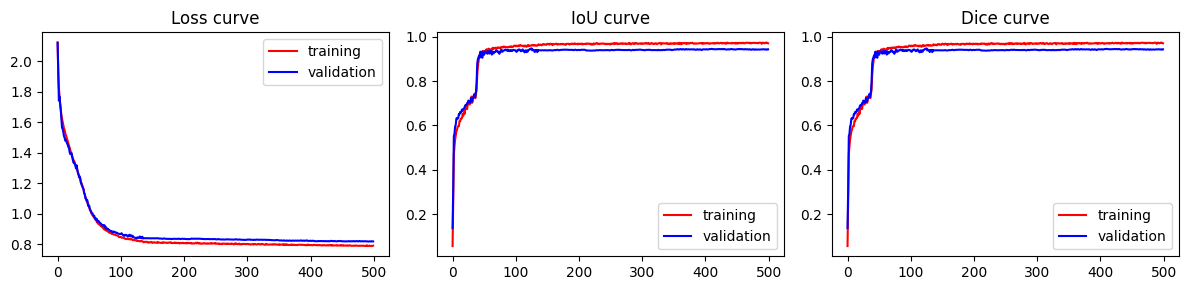

In [ ]:
# Plot loss curves =============================================================
fig, ax = plt.subplots(1,3, figsize=(12, 3))

ax[0].plot(store_train_loss, 'r')
ax[0].plot(store_val_loss, 'b')
ax[0].set_title('Loss curve')
ax[0].legend(['training', 'validation'])

ax[1].plot(store_train_iou, 'r')
ax[1].plot(store_val_iou, 'b')
ax[1].set_title('IoU curve')
ax[1].legend(['training', 'validation'])

ax[2].plot(store_train_iou, 'r')
ax[2].plot(store_val_iou, 'b')
ax[2].set_title('Dice curve')
ax[2].legend(['training', 'validation'])

fig.tight_layout()

save_fig_dir = "/content/drive/MyDrive/Wound_tissue_segmentation/plots/"
if not os.path.exists(save_fig_dir): os.makedirs(save_fig_dir)

fig.savefig(os.path.join(save_fig_dir, model_name + '.png'))

**Inference**

In [ ]:
# ====================================================================
# ĐỒNG BỘ HÓA CELL INFERENCE CHO MÔ HÌNH 1 (MiT + pscSE)
# Thay thế toàn bộ cell Inference cũ trong notebook MiT bằng cell này
# ====================================================================

import torch
import os
import cv2
import numpy as np
import json
import warnings
from PIL import Image
from torch.utils.data import DataLoader
warnings.filterwarnings('ignore')

# 1. Tải mô hình tốt nhất (Đảm bảo biến DEVICE đã được định nghĩa là cuda hoặc cpu)
checkpoint = torch.load(os.path.join(checkpoint_loc, 'best_model.pth'), map_location=DEVICE)
model.load_state_dict(checkpoint['state_dict'])
model.eval()
print(f'✅ Loaded best model MiT+pscSE từ epoch {checkpoint["epoch"]}')

# 2. Khởi tạo Test Dataset & DataLoader (Đồng bộ cấu hình num_workers=0)
test_dataset = Dataset(
    list_IDs_test,
    x_test_dir,
    y_test_dir,
    augmentation   = get_validation_augmentation(),
    preprocessing  = get_preprocessing(preprocessing_fn),
    resize         = RESIZE,
    to_categorical = False,
    n_classes      = n_classes,
)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

# 3. Khởi tạo đường dẫn lưu kết quả (Sử dụng đồng bộ cấu trúc thư mục PROJECT_ROOT)
save_dir_pred         = os.path.join(PROJECT_ROOT, 'predictions',             model_name)
save_dir_pred_pal     = os.path.join(PROJECT_ROOT, 'predictions_palette',     model_name)
save_dir_pred_pal_cat = os.path.join(PROJECT_ROOT, 'predictions_palette_cat', model_name)

for d in [save_dir_pred, save_dir_pred_pal, save_dir_pred_pal_cat]:
    os.makedirs(d, exist_ok=True)

palette = [[0,0,0],[255,0,0],[0,255,0],[0,0,255]]
ep      = 1e-6

# 4. Lưu trữ cấu trúc metric theo 2 cách để đảm bảo tính khoa học
metric_raw   = {}   # Để lưu file JSON toàn diện (giữ cấu trúc cũ)
metric_clean = {}   # Để tính toán bảng thống kê Per-class chính xác nhất

# Bộ đếm ở cấp độ toàn bộ Dataset (Dataset-level)
stp = sfp = sfn = 0

# Bộ đếm Per-class (CHỈ tích lũy khi ảnh Ground Truth thực sự có label đó)
class_tp = {c: 0 for c in range(1, n_classes)}
class_fp = {c: 0 for c in range(1, n_classes)}
class_fn = {c: 0 for c in range(1, n_classes)}
class_n  = {c: 0 for c in range(1, n_classes)}  # Số lượng ảnh thực tế có chứa nhãn c

iter_loader = iter(test_loader)

# 5. Vòng lặp Inference qua từng ảnh trong tập Test
for idx in range(len(list_IDs_test)):

    tp = fp = fn = 0
    name = os.path.splitext(list_IDs_test[idx])[0]
    metric_raw[name]   = {}
    metric_clean[name] = {}

    image, gt_mask = next(iter_loader)

    # Dự đoán từ mô hình MiT
    with torch.no_grad():
        pr_prob = model.predict(image.to(DEVICE))

    # Lấy nhãn lớp có xác suất cao nhất từ một-hot (Argmax)
    pr_mask = torch.argmax(pr_prob, dim=1)

    gt_mask = gt_mask.squeeze().cpu().numpy().astype(np.int64)
    pred    = pr_mask.squeeze().cpu().numpy()

    # Lưu ảnh dự đoán thô (Grayscale)
    cv2.imwrite(os.path.join(save_dir_pred, list_IDs_test[idx]), pred.astype(np.uint8))

    # Tạo và lưu ảnh bảng màu Palette (Ground Truth)
    pal_gt = Image.fromarray(gt_mask.astype(np.uint8)).convert('P')
    pal_gt.putpalette(np.array(palette, dtype=np.uint8))

    # Tạo và lưu ảnh bảng màu Palette (Prediction)
    pal_pr = Image.fromarray(pred.astype(np.uint8)).convert('P')
    pal_pr.putpalette(np.array(palette, dtype=np.uint8))
    pal_pr.save(os.path.join(save_dir_pred_pal, list_IDs_test[idx]))

    # Ghép hai ảnh GT và Prediction song song để đưa vào báo cáo PBL
    cat = Image.new('RGB', (pal_gt.width * 2, pal_gt.height), 'white')
    cat.paste(pal_gt, (0, 0))
    cat.paste(pal_pr, (pal_gt.width, 0))
    cat.save(os.path.join(save_dir_pred_pal_cat, list_IDs_test[idx]))

    # ==============================================================
    # TÍNH TOÁN CÁC CHỈ SỐ ĐÁNH GIÁ (METRICS) ĐỒNG BỘ
    # ==============================================================
    lbl_gt   = set(np.unique(gt_mask)) - {0}
    lbl_pred = set(np.unique(pred))    - {0}

    # Trường hợp FP only: Mô hình đoán sai lớp mô trong khi ảnh gốc không có
    for d in (lbl_pred - lbl_gt):
        fp_pixels = len(np.argwhere(pred == d))
        fp += fp_pixels
        # Chỉ ghi nhận vào file raw JSON, không cộng dồn vào class_n để tránh kéo tụt chỉ số sai lệch
        metric_raw[name][str(d)] = [0, 0, 0, 0]
        print(f'{idx+1:3d} {name}: label {d} | ⚠️  FP only (GT không có label này)')

    # Trường hợp FN only: Ảnh thực tế có lớp mô nhưng mô hình bỏ sót hoàn toàn
    for d in (lbl_gt - lbl_pred):
        fn_pixels = len(np.argwhere(gt_mask == d))
        fn += fn_pixels
        metric_raw[name][str(d)]   = [0, 0, 0, 0]
        metric_clean[name][str(d)] = [0, 0, 0, 0]

        # Ghi nhận chỉ số bỏ sót vào Per-class thống kê
        if d in class_fn:
            class_fn[d] += fn_pixels
            class_n[d]  += 1

        print(f'{idx+1:3d} {name}: label {d} | P:  0.00 R:  0.00 Dice:  0.00 IoU:  0.00  (GT có, mô hình bỏ sót)')

    # Trường hợp trùng khớp (Intersection): Cả ảnh gốc và dự đoán cùng chứa lớp mô
    for c in (lbl_gt & lbl_pred):
        gt_set   = set(zip(*np.where(gt_mask == c)))
        pred_set = set(zip(*np.where(pred    == c)))

        tp_ = len(gt_set & pred_set)
        fp_ = len(pred_set - gt_set)
        fn_ = len(gt_set  - pred_set)

        tp += tp_; fp += fp_; fn += fn_

        p_    = tp_ / (tp_ + fp_ + ep) * 100
        r_    = tp_ / (tp_ + fn_ + ep) * 100
        dice_ = 2*tp_ / (2*tp_ + fp_ + fn_ + ep) * 100
        iou_  = tp_ / (tp_ + fp_ + fn_ + ep) * 100

        print(f'{idx+1:3d} {name}: label {c} | P:{p_:6.2f} R:{r_:6.2f} Dice:{dice_:6.2f} IoU:{iou_:6.2f}')

        metric_raw[name][str(c)]   = [p_, r_, dice_, iou_]
        metric_clean[name][str(c)] = [p_, r_, dice_, iou_]

        # Tích lũy giá trị pixel đúng vào Per-class thống kê tổng
        if c in class_tp:
            class_tp[c] += tp_
            class_fp[c] += fp_
            class_fn[c] += fn_
            class_n[c]  += 1

    stp += tp; sfp += fp; sfn += fn

# Xuất file lưu trữ JSON kết quả chi tiết cho từng ảnh
with open(os.path.join(save_dir_pred, 'metric.json'), 'w') as f:
    json.dump(metric_raw, f, indent=2)

# ==============================================================
# TÍNH TOÁN KẾT QUẢ TỔNG THỂ (Dataset-level Results)
# ==============================================================
siou  = stp / (stp + sfp + sfn + ep) * 100
sprec = stp / (stp + sfp + ep)       * 100
srec  = stp / (stp + sfn + ep)       * 100
sdice = 2*stp / (2*stp + sfp + sfn)  * 100

print('\n' + '='*45)
print(' 📊 Dataset-level Results (Mô hình: MiT + pscSE)')
print('='*45)
print(f'  IoU       : {siou:.4f}')
print(f'  Precision : {sprec:.4f}')
print(f'  Recall    : {srec:.4f}')
print(f'  Dice      : {sdice:.4f}')
print('='*45)

# Xuất file kết quả kết văn bản tổng hợp phục vụ viết báo cáo
with open(os.path.join(save_dir_pred, 'result.txt'), 'w') as f:
    f.write(f'model_name  = {model_name}\n')
    f.write(f'encoder     = {ENCODER}\n')
    f.write(f'best_epoch  = {best_model_epoch}\n')
    f.write(f'iou         = {siou:.4f}\n')
    f.write(f'precision   = {sprec:.4f}\n')
    f.write(f'recall      = {srec:.4f}\n')
    f.write(f'dice        = {sdice:.4f}\n')

# ==============================================================
# BẢNG THỐNG KÊ CHI TIẾT THEO TỪNG LỚP MÔ (Per-class Summary)
# Đã đồng bộ chuẩn hóa: Chỉ tính trên ảnh thực tế có lớp mô đó
# ==============================================================
print("\n" + "="*66)
print(f"{'Label':>6} | {'Precision':>10} | {'Recall':>8} | {'Dice':>8} | {'IoU':>8} | {'N (GT có)':>10}")
print('-' * 66)

for c in range(1, n_classes):
    tp_ = class_tp[c]
    fp_ = class_fp[c]
    fn_ = class_fn[c]
    n_  = class_n[c]

    if n_ == 0:
        print(f"  {c:>4} | {'N/A':>10} | {'N/A':>8} | {'N/A':>8} | {'N/A':>8} | {n_:>10}")
        continue

    p_    = tp_ / (tp_ + fp_ + ep) * 100
    r_    = tp_ / (tp_ + fn_ + ep) * 100
    dice_ = 2*tp_ / (2*tp_ + fp_ + fn_ + ep) * 100
    iou_  = tp_ / (tp_ + fp_ + fn_ + ep) * 100

    print(f"  {c:>4} | {p_:>10.2f} | {r_:>8.2f} | {dice_:>8.2f} | {iou_:>8.2f} | {n_:>10}")

print('-' * 66)
print(f"\nOverall → IoU: {siou:.2f}  Dice: {sdice:.2f}  Prec: {sprec:.2f}  Rec: {srec:.2f}")
print("=" * 66)
print('Ghi chú: N (GT có) = số ảnh thực tế (ground truth) có chứa nhãn mô đó.')
print('         Không tính toán cộng dồn các ảnh mô hình đoán sai (FP only) vào biến N.')
print(f'📂 Toàn bộ kết quả đã được đồng bộ tại: {save_dir_pred}')

✅ Loaded best model MiT+pscSE từ epoch 494
  1 0914: label 1 | P: 98.33 R: 61.93 Dice: 75.99 IoU: 61.28
  1 0914: label 3 | P: 58.48 R: 41.94 Dice: 48.85 IoU: 32.32
  2 0925: label 1 | ⚠️  FP only (GT không có label này)
  2 0925: label 2 | P: 98.14 R: 89.21 Dice: 93.46 IoU: 87.72
  2 0925: label 3 | P: 90.76 R: 77.99 Dice: 83.89 IoU: 72.25
  3 0927: label 1 | P: 85.85 R: 68.99 Dice: 76.50 IoU: 61.95
  3 0927: label 2 | P: 87.41 R: 95.52 Dice: 91.29 IoU: 83.97
  3 0927: label 3 | P: 39.52 R: 94.78 Dice: 55.78 IoU: 38.68
  4 0935: label 1 | ⚠️  FP only (GT không có label này)
  4 0935: label 2 | P: 93.70 R: 90.37 Dice: 92.01 IoU: 85.19
  4 0935: label 3 | P: 57.49 R: 89.10 Dice: 69.89 IoU: 53.71
  5 0961: label 1 | P: 85.93 R: 82.78 Dice: 84.33 IoU: 72.90
  5 0961: label 2 | P: 84.34 R: 82.36 Dice: 83.34 IoU: 71.44
  5 0961: label 3 | P: 75.22 R: 84.65 Dice: 79.66 IoU: 66.19
  6 0962: label 1 | P: 14.74 R:100.00 Dice: 25.69 IoU: 14.74
  6 0962: label 2 | P:100.00 R: 22.92 Dice: 37.30 Io